# Exploratory Data Analysis - Bank Term Deposit Dataset

This notebook covers EDA the same way as the reference statistics guide:
central tendency, spread, shape, hypothesis testing, correlation,
multicollinearity, categorical association tests, missing value treatment,
outlier detection, probability distributions, and feature engineering.

Every concept is explained first, then applied to the real dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (7, 4)


In [2]:
train = pd.read_csv('train.csv')
train['y'] = (train['subscribed'] == 'yes').astype(int)
train.shape


(31647, 19)

In [3]:
train.head()


,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed,y
0,26110,56,admin.,married,unknown,no,1933,no,no,telephone,19,nov,44,2,-1,0,unknown,no,0
1,40576,31,unknown,married,secondary,no,3,no,no,cellular,20,jul,91,2,-1,0,unknown,no,0
2,15320,27,services,married,secondary,no,891,yes,no,cellular,18,jul,240,1,-1,0,unknown,no,0
3,43962,57,management,divorced,tertiary,no,3287,no,no,cellular,22,jun,867,1,84,3,success,yes,1
4,29842,31,technician,married,secondary,no,119,yes,no,cellular,4,feb,380,1,-1,0,unknown,no,0


In [4]:
train.dtypes


ID             int64
age            int64
job           object
marital       object
education     object
default       object
balance        int64
housing       object
loan          object
contact       object
day            int64
month         object
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome      object
subscribed    object
y              int32
dtype: object

In [5]:
train.isnull().sum()


ID            0
age           0
job           0
marital       0
education     0
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
subscribed    0
y             0
dtype: int64

There are no NaN values, but several categorical columns use the string
`"unknown"` to mean missing. We treat `"unknown"` as missing throughout this
notebook. This is checked properly in the Missing Value section below.

## Target Variable

`subscribed` is the label we want to predict. Since it only has two outcomes
(yes/no), it follows a **Bernoulli distribution**: each customer is one
trial, with some probability p of being a subscriber.


In [6]:
train['subscribed'].value_counts()


subscribed
no     27932
yes     3715
Name: count, dtype: int64

In [7]:
train['subscribed'].value_counts(normalize=True).round(4)


subscribed
no     0.8826
yes    0.1174
Name: proportion, dtype: float64

The base rate is about 11.7 percent yes. This means the dataset is
imbalanced, so accuracy alone can be misleading (a model that always predicts
"no" would already score about 88 percent).

## Univariate Analysis - Numeric Variables

Univariate analysis looks at one variable at a time: where its center is,
how spread out it is, and what shape its distribution has.

**Central tendency**
- Mean: average value. Sensitive to outliers.
- Median: middle value. Robust to outliers.
- Mode: most frequent value.

**Spread**
- Variance: average squared distance from the mean.
- Standard deviation (SD): square root of variance, same units as the data.
- IQR: spread of the middle 50 percent of the data (Q3 - Q1).

**Shape**
- Skewness: whether the distribution leans left or right.
- Kurtosis: how heavy the tails are compared to a normal distribution.


In [8]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
train[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,31647.0,40.957247,10.625134,18.0,33.0,39.0,48.0,95.0
balance,31647.0,1363.890258,3028.304293,-8019.0,73.0,450.0,1431.0,102127.0
day,31647.0,15.835466,8.337097,1.0,8.0,16.0,21.0,31.0
duration,31647.0,258.113534,257.118973,0.0,104.0,180.0,318.5,4918.0
campaign,31647.0,2.765697,3.113830,1.0,1.0,2.0,3.0,63.0
pdays,31647.0,39.576042,99.317592,-1.0,-1.0,-1.0,-1.0,871.0
previous,31647.0,0.574272,2.422529,0.0,0.0,0.0,0.0,275.0


In [9]:
summary = pd.DataFrame(index=num_cols)
summary['mean'] = train[num_cols].mean()
summary['median'] = train[num_cols].median()
summary['mode'] = train[num_cols].mode().iloc[0]
summary['variance'] = train[num_cols].var()
summary['std'] = train[num_cols].std()
summary['iqr'] = train[num_cols].quantile(0.75) - train[num_cols].quantile(0.25)
summary['skewness'] = train[num_cols].skew()
summary['kurtosis'] = train[num_cols].kurt()
summary.round(2)


,mean,median,mode,variance,std,iqr,skewness,kurtosis
age,40.96,39.0,32,112.89,10.63,15.0,0.68,0.30
balance,1363.89,450.0,0,9170626.89,3028.30,1358.0,8.00,126.45
day,15.84,16.0,20,69.51,8.34,13.0,0.09,-1.07
duration,258.11,180.0,90,66110.17,257.12,214.5,3.20,19.49
campaign,2.77,2.0,1,9.70,3.11,2.0,4.87,38.06
pdays,39.58,-1.0,-1,9863.98,99.32,0.0,2.64,7.11
previous,0.57,0.0,0,5.87,2.42,0.0,49.30,5236.41


How to read the skewness column (same scale as the reference guide):

- Between -0.5 and 0.5: fairly symmetric
- Between 0.5 and 1 (or -1 and -0.5): moderately skewed
- Beyond 1 or -1: highly skewed

`balance`, `duration`, `campaign`, `pdays` and `previous` are all strongly
right-skewed (large positive skewness), meaning a small number of very large
values are pulling the mean above the median. `pdays` and `previous` also
show very high kurtosis, meaning a small number of extreme values are
producing heavy tails.

`age` is close to symmetric (skewness around 0.7), and `day` is close to
uniform across the month.

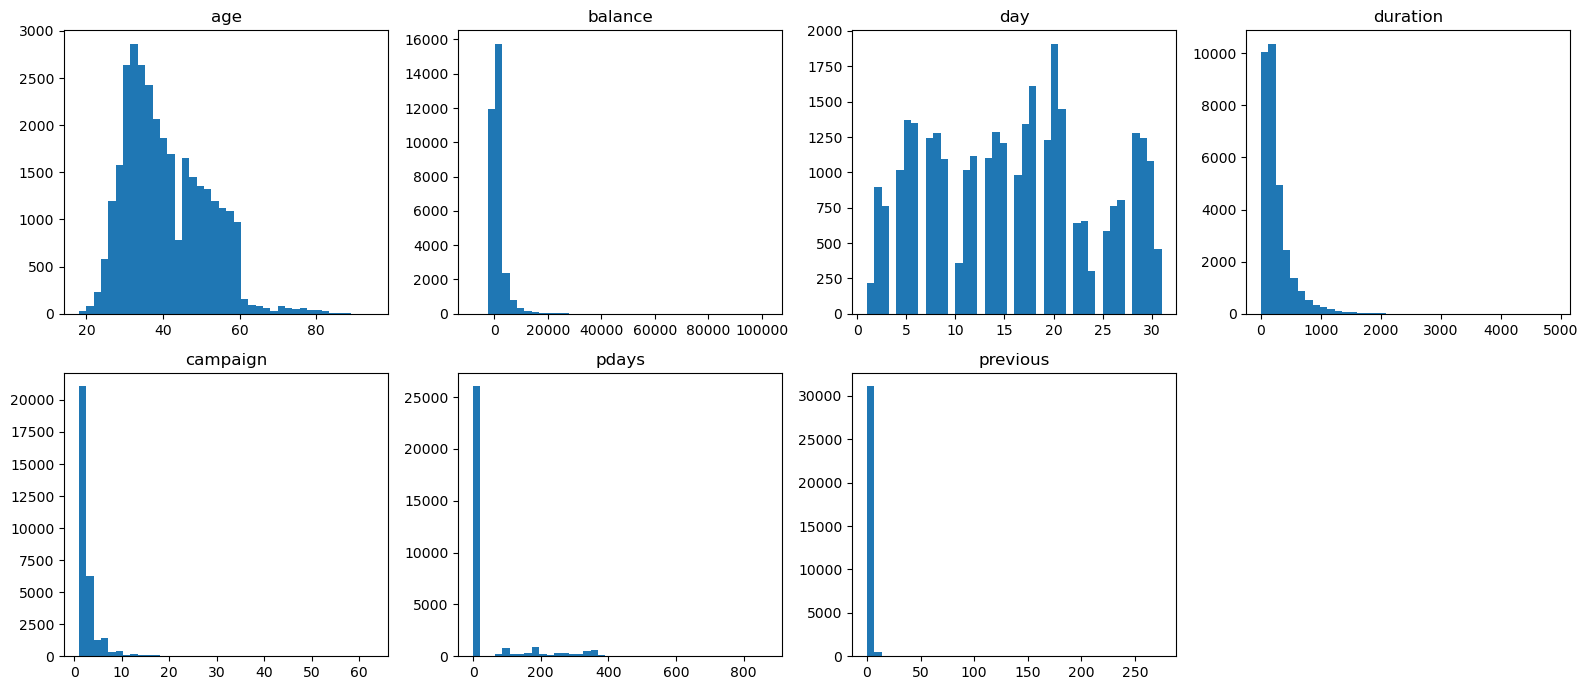

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for i, c in enumerate(num_cols):
    axes[i].hist(train[c], bins=40)
    axes[i].set_title(c)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


`balance`, `duration`, `campaign`, `pdays` and `previous` all show a tall
bar near zero and a long thin tail to the right, matching the positive
skewness numbers above.

## Percentiles

A percentile is the cutoff below which a given percentage of the data falls.
The median is the 50th percentile. Percentiles are useful for understanding
relative standing and for setting outlier cutoffs (as used below).


In [11]:
for c in ['balance', 'duration']:
    p = train[c].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    print(c)
    print(p.round(1))
    print()


balance
0.10        0.0
0.25       73.0
0.50      450.0
0.75     1431.0
0.90     3585.4
0.95     5768.0
0.99    13187.6
Name: balance, dtype: float64

duration
0.10      59.0
0.25     104.0
0.50     180.0
0.75     318.5
0.90     546.4
0.95     752.0
0.99    1259.0
Name: duration, dtype: float64



For `balance`: 50 percent of customers hold under about 450, while the
top 1 percent hold well over 10,000. This gap between the median and the 99th
percentile is exactly what right skewness looks like in percentile terms.

## Outlier Detection

**IQR method**: a value is an outlier if it falls below Q1 - 1.5*IQR or above
Q3 + 1.5*IQR. The 1.5 multiplier is a standard compromise: 1x IQR is too
strict and flags too many normal points, 2x IQR is too lenient and misses
real extremes.

**Z-score method**: a value is an outlier if it is more than 3 standard
deviations from the mean. This connects to the 68-95-99.7 rule for a normal
distribution: about 99.7 percent of values should fall within 3 SD of the
mean, so anything beyond that is rare.

Both methods are applied below to `balance` and `duration`.


In [12]:
def iqr_outlier_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

for c in ['balance', 'duration']:
    lower, upper = iqr_outlier_bounds(train[c])
    pct_outliers = ((train[c] < lower) | (train[c] > upper)).mean()
    print(f'{c}: IQR bounds = [{lower:.1f}, {upper:.1f}]  outliers = {pct_outliers:.2%}')


balance: IQR bounds = [-1964.0, 3468.0]  outliers = 10.42%
duration: IQR bounds = [-217.8, 640.2]  outliers = 7.23%


In [13]:
def zscore_outlier_pct(series):
    z = (series - series.mean()) / series.std()
    return (z.abs() > 3).mean()

for c in ['balance', 'duration']:
    print(f'{c}: |z| > 3 outlier share = {zscore_outlier_pct(train[c]):.2%}')


balance: |z| > 3 outlier share = 1.66%
duration: |z| > 3 outlier share = 2.11%


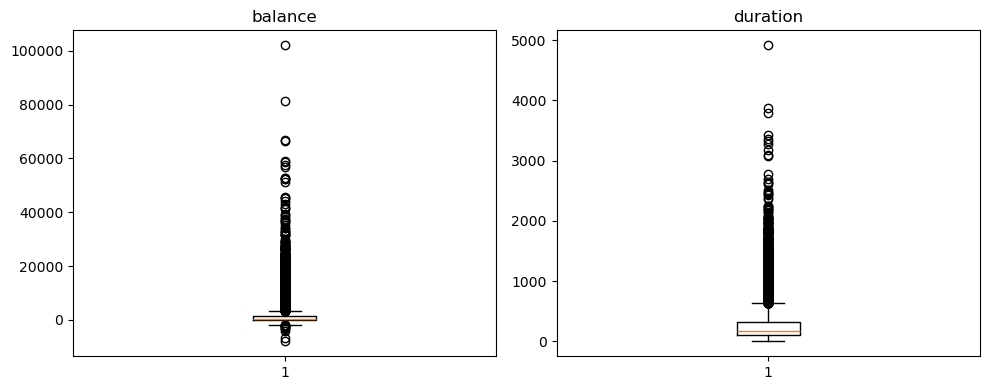

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(train['balance'], vert=True)
axes[0].set_title('balance')
axes[1].boxplot(train['duration'], vert=True)
axes[1].set_title('duration')
plt.tight_layout()
plt.show()


**Treatment decision.** Both methods agree these are heavy-tailed
variables with a real minority of extreme values (large account balances,
very long calls), not data entry errors. Following the reference guide's
options (remove, cap, or keep), we choose to **keep** the raw values, because:

- A high `balance` is a genuine business signal for having surplus money to
  invest, not noise.
- A long `duration` reflects a genuinely engaged conversation.

If a model needed the raw values to be less extreme, the standard fix would
be a log transform, shown below just as an illustration (not applied to the
modeling data).

In [15]:
balance_shifted = train['balance'] - train['balance'].min() + 1
log_balance = np.log(balance_shifted)
print('skewness before log transform:', round(train['balance'].skew(), 2))
print('skewness after log transform :', round(log_balance.skew(), 2))


skewness before log transform: 8.0
skewness after log transform : 0.32


The log transform pulls skewness from a very high positive number down
much closer to zero, which is why it is the standard fix when a model (such
as plain linear/logistic regression on raw features) needs closer-to-normal
inputs.

## Missing Value Treatment

The reference guide lists deletion, mean/median/mode imputation, forward
fill, interpolation, regression imputation, multiple imputation, and
treating "missing" as its own category.

In this dataset the actual missing-value marker is the string `"unknown"`,
not NaN, and it appears only in a few categorical columns.


In [16]:
cat_cols_with_unknown = ['job', 'education', 'contact', 'poutcome']
for c in cat_cols_with_unknown:
    pct_unknown = (train[c] == 'unknown').mean()
    print(f'{c}: {pct_unknown:.2%} unknown')


job: 0.65% unknown
education: 4.15% unknown
contact: 29.00% unknown
poutcome: 81.93% unknown


Decision for each column, following the "missing as its own category"
approach from the reference guide, rather than imputing a value we do not
actually know:

- `job` (0.7 percent unknown), `education` (4.2 percent unknown): the share
  is small; `"unknown"` is left as its own category rather than guessing a
  job or education level.
- `contact` (29 percent unknown), `poutcome` (82 percent unknown): the share
  is large and is not random noise. `poutcome` is unknown mainly because most
  customers were never in a prior campaign, so imputing a value would
  invent information that does not exist. `"unknown"` is kept as a
  meaningful category in both cases.

No rows are deleted and no values are imputed, because the missingness itself
carries information (never previously contacted, contact channel not
recorded) rather than being a random gap.

## Bivariate Analysis: Continuous vs Continuous

**Covariance** shows the direction only (positive or negative), and its size
depends on the units of the variables, so it cannot be compared across
variable pairs.

**Correlation** rescales covariance to a value between -1 and +1, so it shows
both direction and strength on a common scale.
- Pearson correlation: measures a straight-line relationship.
- Spearman correlation: measures a monotonic relationship (does not have to
  be a straight line), using ranks instead of raw values.


In [17]:
cov_matrix = train[num_cols].cov()
cov_matrix.round(1)


,age,balance,day,duration,campaign,pdays,previous
age,112.9,3322.0,-1.0,-10.6,0.2,-23.2,0.1
balance,3322.0,9170626.9,87.4,18900.8,-113.5,537.9,101.6
day,-1.0,87.4,69.5,-69.2,4.1,-72.6,-1.0
duration,-10.6,18900.8,-69.2,66110.2,-64.3,13.5,1.1
campaign,0.2,-113.5,4.1,-64.3,9.7,-27.1,-0.3
pdays,-23.2,537.9,-72.6,13.5,-27.1,9864.0,103.2
previous,0.1,101.6,-1.0,1.1,-0.3,103.2,5.9


In [18]:
corr_pearson = train[num_cols].corr(method='pearson')
corr_pearson.round(2)


,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.01,-0.02,0.01
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.01
day,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,0.00,0.00
campaign,0.01,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,0.00,-0.09,1.00,0.43
previous,0.01,0.01,-0.05,0.00,-0.03,0.43,1.00


In [19]:
corr_spearman = train[num_cols].corr(method='spearman')
corr_spearman.round(2)


,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.09,-0.01,-0.04,0.04,-0.02,-0.01
balance,0.09,1.00,-0.00,0.04,-0.03,0.07,0.08
day,-0.01,-0.00,1.00,-0.06,0.14,-0.09,-0.08
duration,-0.04,0.04,-0.06,1.00,-0.11,0.03,0.03
campaign,0.04,-0.03,0.14,-0.11,1.00,-0.11,-0.10
pdays,-0.02,0.07,-0.09,0.03,-0.11,1.00,0.99
previous,-0.01,0.08,-0.08,0.03,-0.10,0.99,1.00


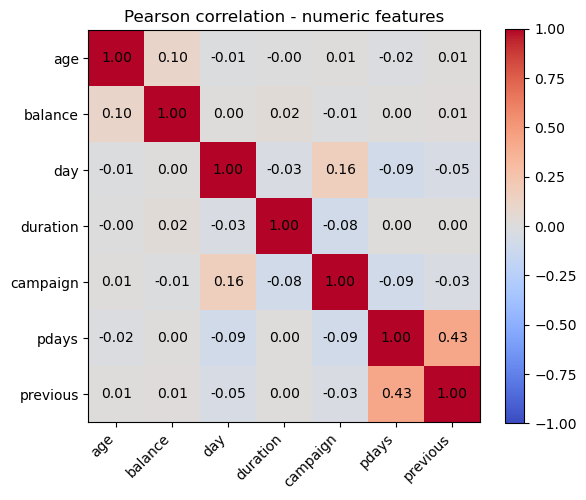

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_pearson, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr_pearson.iloc[i, j]:.2f}', ha='center', va='center')
plt.colorbar(im)
plt.title('Pearson correlation - numeric features')
plt.tight_layout()
plt.show()


The strongest pair is `pdays` and `previous` (customers contacted more
times before also tend to have a shorter gap since last contact). All other
pairs are weak, so multicollinearity between numeric features looks limited,
which is confirmed with VIF below.

**Multicollinearity and VIF.** Multicollinearity means two or more
predictors carry overlapping information, which makes regression
coefficients unstable and hard to interpret. VIF (Variance Inflation Factor)
measures this for each variable by regressing it against all the other
variables and checking how much of its variance is already explained by
them.

VIF = 1 / (1 - R-squared)

Rule of thumb: VIF above 5 signals high collinearity, above 10 is severe.


In [21]:
X_vif = train[num_cols].copy()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()   # scaling first, standard practice for VIF
vif_table = pd.DataFrame()
vif_table['feature'] = num_cols
vif_table['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(num_cols))]
vif_table.round(2)


,feature,VIF
0,age,1.01
1,balance,1.01
2,day,1.03
3,duration,1.01
4,campaign,1.04
5,pdays,1.24
6,previous,1.23


All VIF values are close to 1, well under the 5 threshold. This means
none of the numeric features are redundant with each other, so no feature
needs to be dropped for multicollinearity reasons.

**Correlation is not causation.** Suppose we notice that customers with
higher `balance` also have a higher subscription rate. It would be a mistake
to conclude that having a high balance directly causes someone to subscribe.
A more likely explanation is a hidden common factor, such as overall income
or financial discipline, which drives both a higher balance and a greater
willingness to invest. The correct way to investigate this is to control for
other variables in a model (as done in the modeling notebook) rather than
reading a single correlation number as proof of a causal effect.

## Bivariate Analysis: Continuous vs Categorical

To compare a continuous variable's mean across two groups, we use a t-test
(or z-test for large samples). To compare means across three or more groups,
we use ANOVA. Both are hypothesis tests, so we first set up the hypothesis
testing framework.

**Hypothesis testing recap**
- Null hypothesis (H0): assumes no difference / no relationship.
- Alternate hypothesis (H1): assumes a real difference / relationship exists.
- p-value: probability of seeing data this extreme if H0 were actually true.
  A small p-value is surprising under H0, and is evidence against it.
- Alpha: the threshold we decide in advance (commonly 0.05). If p <= alpha,
  we reject H0.
- This dataset has over 31,000 rows, so a two-sample z-test and a two-sample
  t-test give essentially the same answer; the t-test is used below since it
  is valid at any sample size.


In [22]:
yes_balance = train.loc[train['y'] == 1, 'balance']
no_balance = train.loc[train['y'] == 0, 'balance']

print('mean balance, subscribed = yes:', round(yes_balance.mean(), 1))
print('mean balance, subscribed = no :', round(no_balance.mean(), 1))

t_stat, p_value = stats.ttest_ind(yes_balance, no_balance, equal_var=False)
print('t-statistic:', round(t_stat, 3))
print('p-value    :', p_value)


mean balance, subscribed = yes: 1785.8
mean balance, subscribed = no : 1307.8
t-statistic: 8.114
p-value    : 6.267048565195971e-16


H0: mean balance is the same for subscribers and non-subscribers.
H1: mean balance differs between the two groups.

The p-value is far below 0.05, so H0 is rejected: balance genuinely differs
between subscribers and non-subscribers, matching the positive correlation
seen earlier between balance and the target.

In [23]:
job_groups = [train.loc[train['job'] == j, 'balance'] for j in train['job'].unique()]
f_stat, p_value_anova = stats.f_oneway(*job_groups)
print('F-statistic:', round(f_stat, 3))
print('p-value    :', p_value_anova)


F-statistic: 31.225
p-value    : 1.4001965683650021e-66


H0: mean balance is the same across all job categories.
H1: at least one job category has a different mean balance.

The p-value is far below 0.05, so H0 is rejected: average balance genuinely
differs by job type (for example, retired and management customers tend to
hold higher balances than blue-collar or student customers).

In [24]:
train.groupby('job')['balance'].mean().sort_values(ascending=False).round(1)


job
retired          2018.1
management       1755.4
self-employed    1700.8
unknown          1626.4
entrepreneur     1544.8
unemployed       1497.7
housemaid        1469.8
student          1412.2
technician       1257.5
admin.           1111.1
blue-collar      1069.6
services         1022.3
Name: balance, dtype: float64

## Bivariate Analysis: Categorical vs Categorical

To test whether two categorical variables are related, we use the
Chi-Square test of independence. It compares the actual counts in each
combination of categories against the counts we would expect if the two
variables were completely unrelated.

H0: the two variables are independent (no relationship).
H1: the two variables are related.


In [25]:
contingency = pd.crosstab(train['housing'], train['subscribed'])
contingency


subscribed,no,yes
housing,,
no,11698,2365
yes,16234,1350


In [26]:
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
print('chi-square statistic:', round(chi2, 2))
print('degrees of freedom  :', dof)
print('p-value             :', p_value_chi2)


chi-square statistic: 629.11
degrees of freedom  : 1
p-value             : 7.801523512528638e-139


The p-value is far below 0.05, so H0 is rejected: whether a customer has
a housing loan is genuinely related to whether they subscribe. Customers
without a housing loan subscribe at a noticeably higher rate, consistent with
having less of their income tied up in EMI payments.

**Degrees of freedom**, used inside this test, is the number of values that
can vary freely once the row and column totals are fixed. For a table with r
rows and c columns, degrees of freedom = (r-1) * (c-1). With a 2x2 table like
this one, that is 1.

In [27]:
for c in ['job', 'education', 'marital', 'poutcome', 'contact']:
    table = pd.crosstab(train[c], train['subscribed'])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    print(f'{c:10s} chi2={chi2:8.2f}  dof={dof}  p-value={p:.2e}')


job        chi2=  588.73  dof=11  p-value=3.60e-119
education  chi2=  175.37  dof=3  p-value=8.82e-38
marital    chi2=  153.28  dof=2  p-value=5.20e-34
poutcome   chi2= 3125.79  dof=3  p-value=0.00e+00
contact    chi2=  735.26  dof=2  p-value=2.19e-160


Every one of these categorical variables shows a p-value far below
0.05, so all of them are significantly related to subscription. This matches
the earlier Information Value ranking, which is really testing the same
underlying question (does this category matter for the target) using a
different, business-oriented number.

## Standard Error, Confidence Interval, and Sample Size

**Standard error (SE)** measures how much a sample mean would be expected to
vary if we repeated the sampling. It shrinks as sample size grows:

SE = SD / sqrt(n)

**Confidence interval (CI)** gives a range around the sample mean that is
likely to contain the true population mean. A 95 percent CI means: if we
repeated this sampling process many times, about 95 percent of the intervals
built this way would contain the true value.


In [28]:
mean_age = train['age'].mean()
std_age = train['age'].std()
n = len(train)
se_age = std_age / np.sqrt(n)

ci_lower = mean_age - 1.96 * se_age
ci_upper = mean_age + 1.96 * se_age

print('mean age       :', round(mean_age, 2))
print('standard error :', round(se_age, 4))
print('95% CI         :', (round(ci_lower, 2), round(ci_upper, 2)))


mean age       : 40.96
standard error : 0.0597
95% CI         : (40.84, 41.07)


Because the sample size here is large (over 31,000 rows), the standard
error is tiny and the confidence interval is extremely narrow: we can be very
confident about the true average age of customers in this population. This
illustrates the SE formula directly: a small sample of 30 customers would
produce a much wider interval than a sample of 31,000.

In [29]:
np.random.seed(42)
small_sample = train['age'].sample(30, random_state=42)
se_small = small_sample.std() / np.sqrt(30)
print('small sample (n=30)  mean:', round(small_sample.mean(), 2), ' SE:', round(se_small, 3))
print('full sample  (n=31647) mean:', round(mean_age, 2), ' SE:', round(se_age, 3))


small sample (n=30)  mean: 42.47  SE: 1.715
full sample  (n=31647) mean: 40.96  SE: 0.06


## Probability Distributions

A probability distribution describes how likely each possible value or
outcome is. Checking which distribution a variable resembles helps decide
which statistical tests are valid and how to model the variable.

- `subscribed` is Bernoulli: a single yes/no outcome per customer.
- `previous` and `campaign` are contact counts, so a Poisson-style count
  distribution is the natural comparison, though real campaign counts are
  usually more spread out ("overdispersed") than a true Poisson variable.
- `age` and `balance` are continuous; the question below is how close they
  come to a Normal distribution.


In [30]:
shapiro_sample = train['age'].sample(2000, random_state=42)
stat, p_value_norm = stats.shapiro(shapiro_sample)
print('Shapiro-Wilk statistic:', round(stat, 4))
print('p-value               :', p_value_norm)


Shapiro-Wilk statistic: 0.9647
p-value               : 1.024543212562447e-21


H0: the variable is normally distributed.
H1: the variable is not normally distributed.

The p-value here is far below 0.05, so H0 is rejected: `age` is not exactly
normal, even though its histogram looked roughly bell-shaped earlier. This is
common with large samples, since the test becomes very sensitive to even
small deviations from normality. The skewness/kurtosis numbers from the
univariate section remain the more practical way to judge how far a
variable is from normal for modeling purposes.

In [31]:
mean_prev = train['previous'].mean()
var_prev = train['previous'].var()
print('previous: mean =', round(mean_prev, 3), ' variance =', round(var_prev, 3))


previous: mean = 0.574  variance = 5.869


For a true Poisson variable, the mean and variance should be roughly
equal. Here the variance (about 5.9) is far larger than the mean (about
0.57), which means `previous` is overdispersed relative to a Poisson
distribution: a small number of customers were contacted many times before,
stretching the variance well beyond what a simple count model would expect.
This is exactly the kind of heavy-tailed count behaviour the skewness and
kurtosis numbers already flagged.

## Feature Engineering

Turning raw variables into a form that is easier for a model to use.

- **Binning** groups a continuous variable into ranges (used heavily in the
  Weight-of-Evidence notebook).
- **Log transform** reduces right skew (shown above for `balance`).
- **Scaling** puts variables on a comparable range, needed for
  distance-based methods (K-Means) or variance-based methods (PCA), though
  not required for tree models like XGBoost.
- **Encoding** turns categories into numbers: one-hot encoding creates a 0/1
  column per category; target/WoE encoding replaces a category with a
  number that reflects its relationship with the target (used in the
  modeling notebook).
- **Feature creation** combines existing variables into a new, more directly
  useful one.


In [32]:
age_bins = pd.cut(train['age'], bins=[17, 30, 40, 50, 60, 100],
                   labels=['18-30', '31-40', '41-50', '51-60', '60+'])
train.groupby(age_bins, observed=True)['y'].mean().round(3)


age
18-30    0.161
31-40    0.103
41-50    0.093
51-60    0.101
60+      0.417
Name: y, dtype: float64

In [33]:
scaled_balance = (train['balance'] - train['balance'].mean()) / train['balance'].std()
minmax_balance = (train['balance'] - train['balance'].min()) / (train['balance'].max() - train['balance'].min())
pd.DataFrame({'raw': train['balance'].head(),
              'standardized': scaled_balance.head().round(3),
              'min_max': minmax_balance.head().round(3)})


,raw,standardized,min_max
0,1933,0.188,0.090
1,3,-0.449,0.073
2,891,-0.156,0.081
3,3287,0.635,0.103
4,119,-0.411,0.074


In [34]:
# example feature creation: contact effort per previous relationship
train['contact_intensity'] = train['campaign'] / (train['previous'] + 1)
train[['campaign', 'previous', 'contact_intensity']].head()


,campaign,previous,contact_intensity
0,2,0,2.00
1,2,0,2.00
2,1,0,1.00
3,1,3,0.25
4,1,0,1.00


`contact_intensity` combines two raw counters into one ratio: how many
times this customer was contacted in the current campaign relative to their
prior contact history. A high value flags customers being called heavily
despite little or no prior relationship.

## Summary

- Target is imbalanced: about 11.7 percent subscribe (Bernoulli, base rate).
- `balance`, `duration`, `campaign`, `pdays`, `previous` are right-skewed with
  heavy tails (high kurtosis); `age` is close to symmetric.
- IQR and Z-score methods agree on a genuine minority of extreme values in
  `balance` and `duration`; these are kept as real business signal rather
  than removed.
- `"unknown"` is the real missing-value marker in this dataset, kept as its
  own category rather than imputed, since the missingness itself is
  informative.
- Numeric features show low correlation and low VIF with each other, so no
  multicollinearity concerns among them.
- t-test, ANOVA, and Chi-square all confirm (p < 0.05) that balance, job, and
  every checked categorical variable are significantly related to the
  target.
- Age is not perfectly Normal (Shapiro-Wilk) and `previous` is overdispersed
  relative to Poisson; both point to heavy-tailed, non-textbook
  distributions, which is why WoE binning (next notebook) is preferred over
  assuming linear or normal behaviour.
